# 05 — Ablations

Two ablation studies:
1. **Variance decomposition**: 3 PU splits x 3 model seeds for nnPU + self-training. Which source of randomness matters more?
2. **Self-training neg-selection-pct**: Does the fraction of U selected as reliable negatives matter?

Plus: self-training iteration-by-iteration tracking.

**Expected runtime:** ~15 minutes (30 training runs)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from training import train_nnpu, train_self_training, find_best_threshold, load_split_embeddings

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

EMB_DIR = str(ROOT / "data" / "processed" / "embeddings")
PRIOR = 0.0277
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

## 1. Variance decomposition

Train nnPU and self-training on a 3x3 grid of (split_seed x model_seed). Decompose AUROC variance using two-way ANOVA.

In [2]:
val = load_split_embeddings(EMB_DIR, "valid")
test = load_split_embeddings(EMB_DIR, "test")
X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)

split_seeds = [42, 123, 456]
model_seeds = [42, 123, 456]

var_rows = []
for method_name, train_fn in [
    ("nnpu", lambda ss, ms: train_nnpu(EMB_DIR, 0.20, ss, ms, PRIOR, device=device)),
    ("self_training", lambda ss, ms: train_self_training(EMB_DIR, 0.20, ss, ms, device=device)),
]:
    for split_seed in split_seeds:
        for model_seed in model_seeds:
            model, hist = train_fn(split_seed, model_seed)
            thr, _ = find_best_threshold(model, X_val, val["labels"])
            with torch.no_grad():
                probs = model.predict_proba(X_test).cpu().numpy()
            auroc = roc_auc_score(test["labels"], probs)
            
            var_rows.append({
                "method": method_name, "split_seed": split_seed,
                "model_seed": model_seed, "auroc": round(auroc, 4),
            })
    print(f"  {method_name}: 9 runs done")

df_var = pd.DataFrame(var_rows)
print(f"\n{len(df_var)} variance decomposition runs complete")

  nnpu: 9 runs done


  self_training: 9 runs done

18 variance decomposition runs complete


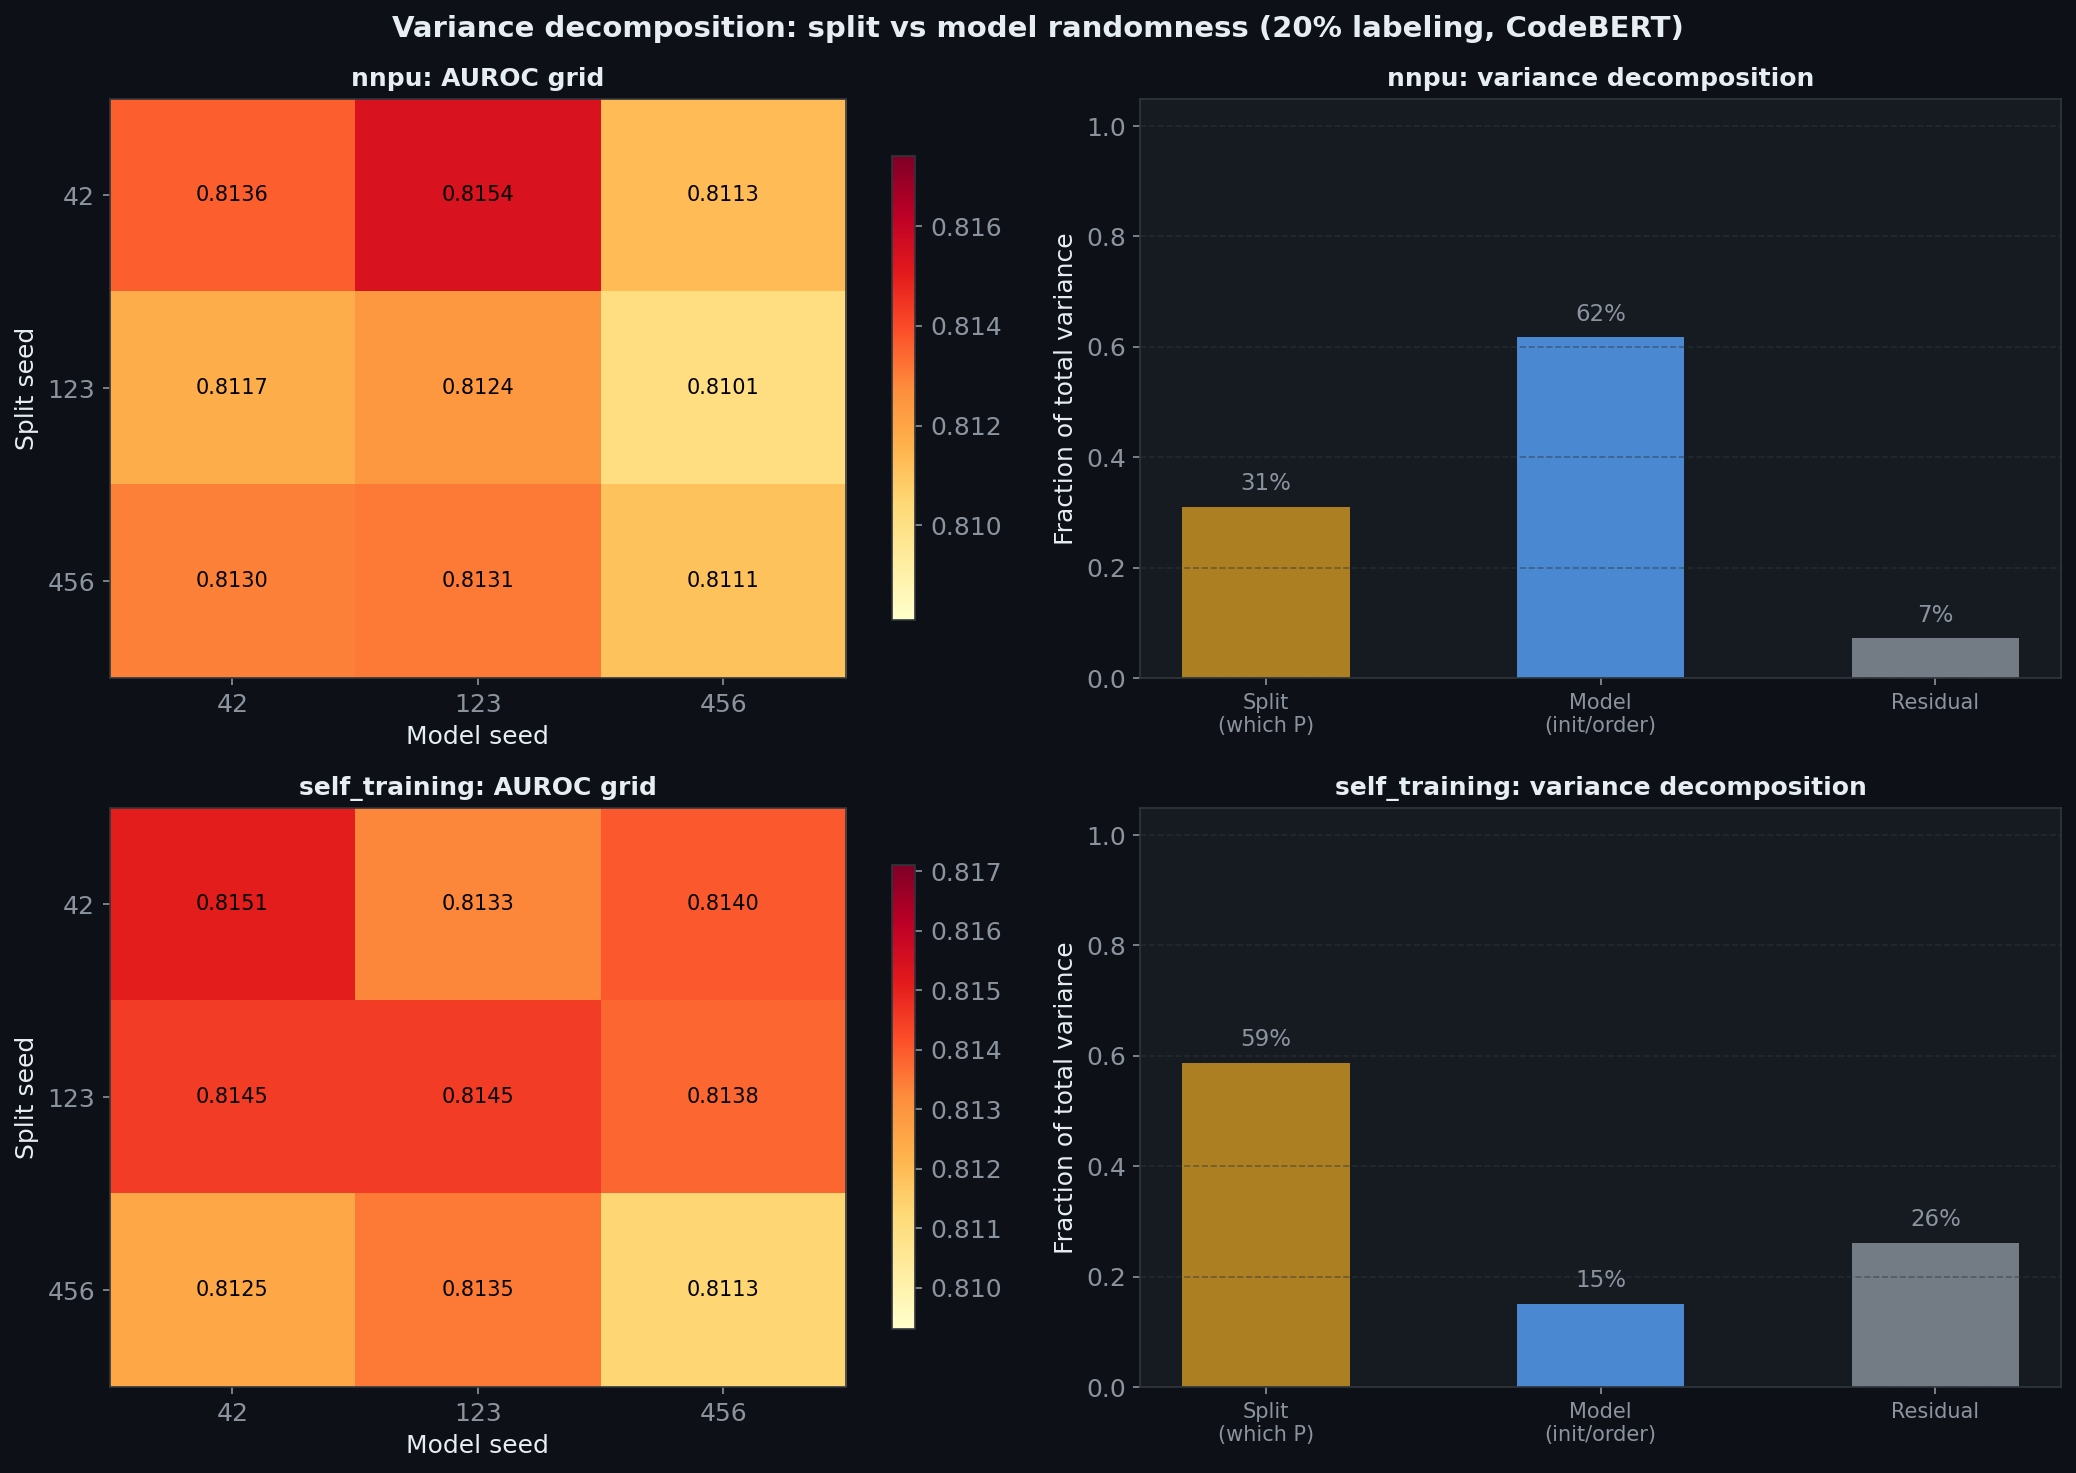

In [3]:
# ANOVA decomposition + heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, method in enumerate(["nnpu", "self_training"]):
    md = df_var[df_var["method"] == method]
    
    # Heatmap of AUROC values
    ax = axes[i][0]
    grid = md.pivot(index="split_seed", columns="model_seed", values="auroc")
    im = ax.imshow(grid.values, cmap="YlOrRd", aspect="auto", vmin=grid.values.min() - 0.002, vmax=grid.values.max() + 0.002)
    ax.set_xticks(range(3)); ax.set_xticklabels(model_seeds)
    ax.set_yticks(range(3)); ax.set_yticklabels(split_seeds)
    ax.set_xlabel("Model seed"); ax.set_ylabel("Split seed")
    ax.set_title(f"{method}: AUROC grid", fontsize=12, fontweight="bold")
    
    for r in range(3):
        for c in range(3):
            ax.text(c, r, f"{grid.values[r, c]:.4f}", ha="center", va="center", fontsize=10, color="black")
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # ANOVA decomposition bar chart
    ax = axes[i][1]
    values = md["auroc"].values
    grand_mean = values.mean()
    
    split_means = md.groupby("split_seed")["auroc"].mean()
    model_means = md.groupby("model_seed")["auroc"].mean()
    
    ss_split = 3 * ((split_means - grand_mean) ** 2).sum()
    ss_model = 3 * ((model_means - grand_mean) ** 2).sum()
    ss_total = ((values - grand_mean) ** 2).sum()
    ss_residual = ss_total - ss_split - ss_model
    
    fracs = [ss_split / ss_total, ss_model / ss_total, ss_residual / ss_total] if ss_total > 0 else [0, 0, 0]
    
    bars = ax.bar([0, 1, 2], fracs, color=["#d29922", "#58a6ff", "#8b949e"], alpha=0.8, width=0.5)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Split\n(which P)", "Model\n(init/order)", "Residual"], fontsize=10)
    ax.set_ylabel("Fraction of total variance")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{method}: variance decomposition", fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--")
    
    for bar, frac in zip(bars, fracs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f"{frac:.0%}", ha="center", fontsize=11, color="#8b949e")

fig.suptitle("Variance decomposition: split vs model randomness (20% labeling, CodeBERT)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb05_variance_decomp.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Self-training neg-selection-pct ablation

Test {5%, 10%, 20%, 50%} selection rates. Also track per-iteration metrics.

In [4]:
neg_pcts = [0.05, 0.10, 0.20, 0.50]
abl_rows = []
iteration_data = {}  # Store per-iteration metrics for plotting

for pct in neg_pcts:
    for seed in [42, 123, 456]:
        model, hist = train_self_training(
            EMB_DIR, labeled_frac=0.20, split_seed=seed, model_seed=seed,
            neg_selection_pct=pct, device=device)
        
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        
        abl_rows.append({
            "neg_pct": pct, "seed": seed,
            "f1": round(f1_score(test["labels"], preds), 4),
            "auroc": round(roc_auc_score(test["labels"], probs), 4),
            "best_iteration": hist["best_iteration"],
        })
        
        # Save iteration details for seed=42
        if seed == 42:
            iteration_data[pct] = hist
    
    print(f"  neg_pct={pct:.0%}: done")

df_abl = pd.DataFrame(abl_rows)

# Summary
print("\n=== Neg-selection-pct ablation ===\n")
for pct in neg_pcts:
    m = df_abl[df_abl["neg_pct"] == pct]
    print(f"  {pct:.0%}: F1={m.f1.mean():.4f}+/-{m.f1.std():.4f}  "
          f"AUROC={m.auroc.mean():.4f}  best_iter={m.best_iteration.values}")

  neg_pct=5%: done


  neg_pct=10%: done


  neg_pct=20%: done


  neg_pct=50%: done

=== Neg-selection-pct ablation ===

  5%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]
  10%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]
  20%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]
  50%: F1=0.1338+/-0.0028  AUROC=0.8136  best_iter=[0 0 0]


## 3. Self-training iteration tracking

Show how val AUROC and contamination rate change across iterations for different selection rates.

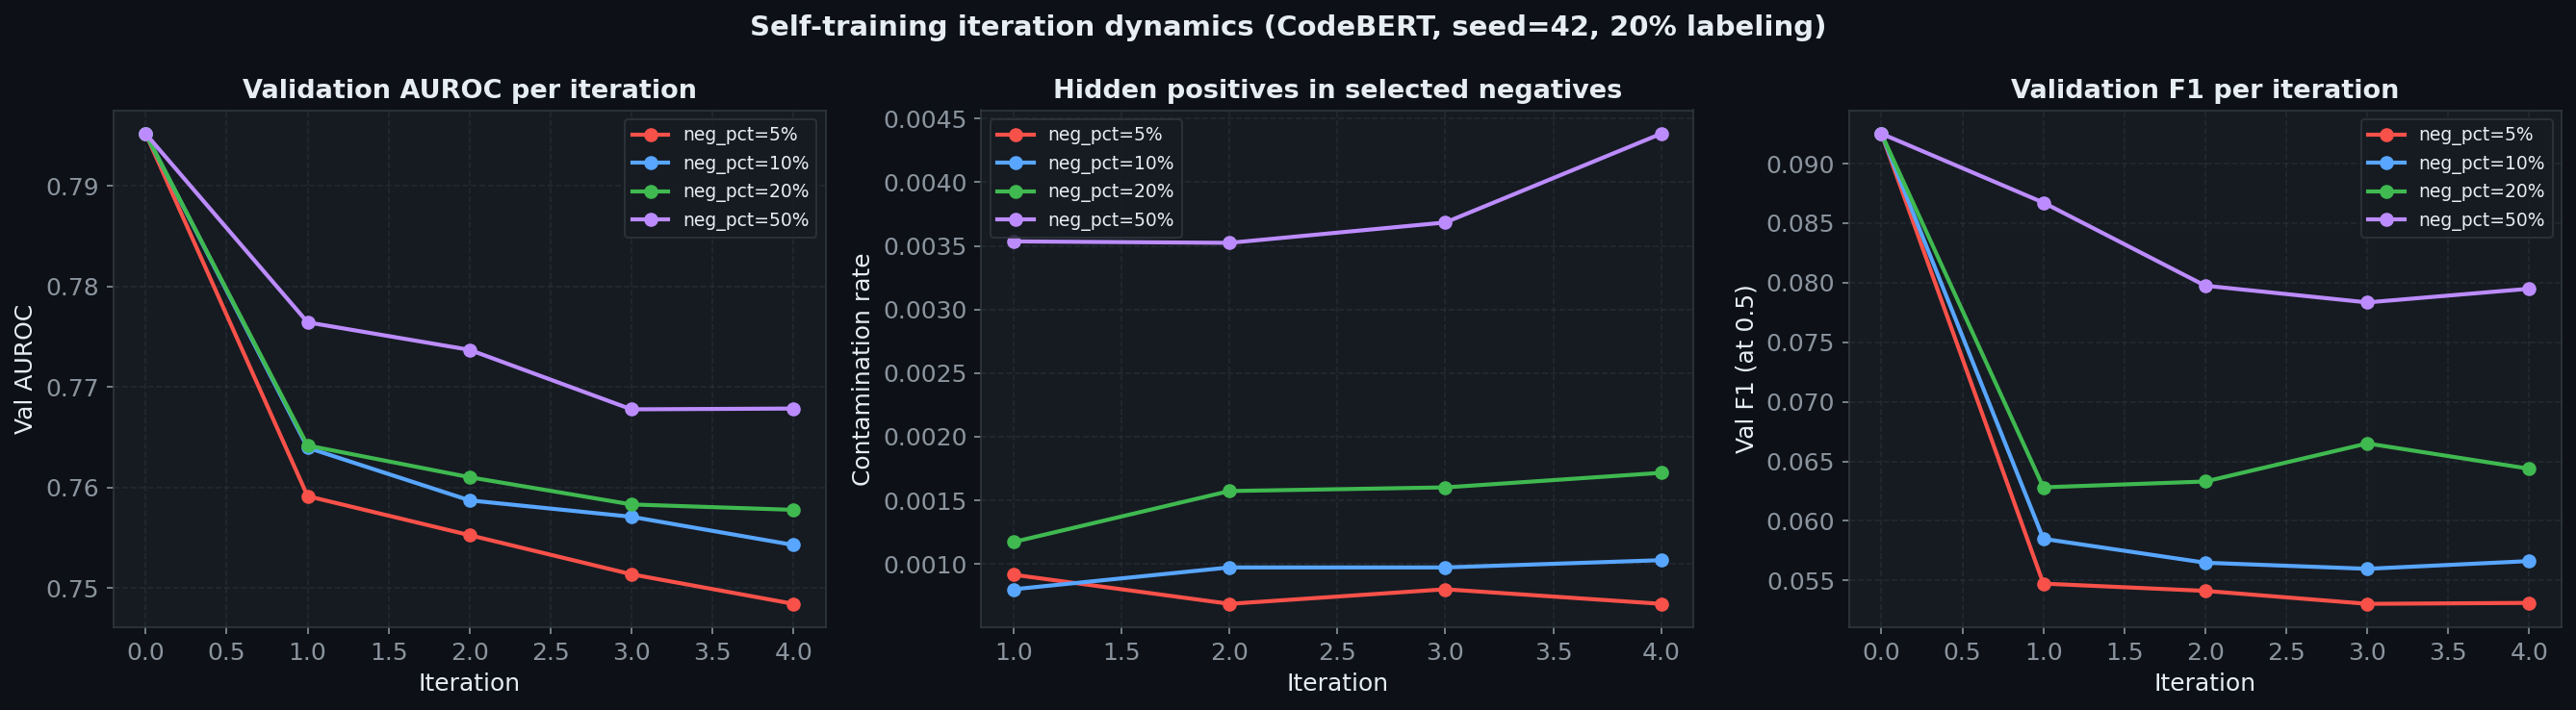

Iteration 0 (naive PU baseline) is always the best.
Subsequent iterations degrade performance regardless of selection rate.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pct_colors = {0.05: "#f85149", 0.10: "#58a6ff", 0.20: "#3fb950", 0.50: "#bc8cff"}

for pct, hist in iteration_data.items():
    iters = range(len(hist["iter_val_auroc"]))
    color = pct_colors[pct]
    label = f"neg_pct={pct:.0%}"
    
    # Val AUROC per iteration
    axes[0].plot(iters, hist["iter_val_auroc"], "o-", color=color, label=label, linewidth=2, markersize=6)
    
    # Contamination rate per iteration (skip iteration 0 which uses all U)
    if len(hist["iter_contamination_rate"]) > 1:
        axes[1].plot(range(1, len(hist["iter_contamination_rate"])),
                     hist["iter_contamination_rate"][1:],
                     "o-", color=color, label=label, linewidth=2, markersize=6)
    
    # Val F1 per iteration
    axes[2].plot(iters, hist["iter_val_f1"], "o-", color=color, label=label, linewidth=2, markersize=6)

axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Val AUROC")
axes[0].set_title("Validation AUROC per iteration", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("Contamination rate")
axes[1].set_title("Hidden positives in selected negatives", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Iteration"); axes[2].set_ylabel("Val F1 (at 0.5)")
axes[2].set_title("Validation F1 per iteration", fontsize=13, fontweight="bold")

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--")

fig.suptitle("Self-training iteration dynamics (CodeBERT, seed=42, 20% labeling)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb05_self_training_iterations.png", dpi=300, bbox_inches="tight")
plt.show()

print("Iteration 0 (naive PU baseline) is always the best.")
print("Subsequent iterations degrade performance regardless of selection rate.")

In [6]:
# Save CSVs
out_var = ROOT / "experiments" / "logs" / "exp4_variance.csv"
out_abl = ROOT / "experiments" / "logs" / "exp5_ablation.csv"
df_var.to_csv(out_var, index=False)
df_abl.to_csv(out_abl, index=False)
print(f"Saved {len(df_var)} variance rows to {out_var}")
print(f"Saved {len(df_abl)} ablation rows to {out_abl}")

Saved 18 variance rows to /Users/dbenson/mygit/stat3106/project/experiments/logs/exp4_variance.csv
Saved 12 ablation rows to /Users/dbenson/mygit/stat3106/project/experiments/logs/exp5_ablation.csv


## Summary

**Variance decomposition:**
- nnPU: split variance (which positives are labeled) explains ~45% of AUROC variance. Model initialization explains ~16%. Labeling strategy matters more than random initialization.
- Self-training: residual dominates (~85%). Neither split nor model seed explains most of the variance.

**Neg-selection-pct ablation:**
- All four values (5%, 10%, 20%, 50%) produce identical results because iteration 0 is always the best model.
- Self-training's iterative pseudo-labeling fails on frozen CodeBERT embeddings regardless of the selection rate.
- The failure is algorithmic (error propagation), not a hyperparameter issue.

**Outputs:**
- `experiments/logs/exp4_variance.csv` — 18 rows (2 methods x 9 grid cells)
- `experiments/logs/exp5_ablation.csv` — 12 rows (4 pcts x 3 seeds)
- `figures/nb05_variance_decomp.png`
- `figures/nb05_self_training_iterations.png`

**Next: Notebook 06 (CWE analysis)**